<a href="https://colab.research.google.com/github/kaansoftware34/softito_calismalar_face2face/blob/main/derin_ogrenme_goruntu_isleme070726.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Derin Öğrenme ile Görüntü İşleme: CNN, U-Net ve Mask R-CNN

Bu not defteri, görüntü işlemede en çok kullanılan üç derin öğrenme mimarisini
**kavramsal açıklama + satır satır yorumlanmış kod** formatında ele alır:

1. **CNN (Convolutional Neural Network)** — Görüntü sınıflandırma
2. **U-Net** — Piksel bazlı segmentasyon (görüntüdeki her pikseli sınıflandırma)
3. **Mask R-CNN** — Nesne tespiti + örnek (instance) segmentasyonu

> **Not:** Bu defter eğitim amaçlıdır. Küçük/sentetik veri veya `torchvision`
> gibi hazır ağırlıklarla çalışacak şekilde tasarlanmıştır, böylece kod hiçbir
> ek veri seti indirmeden çalıştırılabilir ve mimarilerin nasıl kurulduğu
> görülebilir. Gerçek bir projede kendi veri setinizle eğitim (training)
> döngüsünü genişletmeniz gerekir.

**Kullanılan kütüphane:** PyTorch (`torch`, `torchvision`)


In [17]:
# Gerekli kütüphaneleri kontrol edip kuruyoruz
# torch: tensör işlemleri ve sinir ağı katmanları için temel kütüphane
# torchvision: hazır modeller (Mask R-CNN dahil) ve görüntü dönüşümleri için
!pip install torch torchvision --quiet


In [18]:
import torch                     # Ana derin öğrenme kütüphanesi (tensörler, autograd)
import torch.nn as nn            # Sinir ağı katmanlarını içerir (Conv2d, Linear, vb.)
import torch.nn.functional as F  # Aktivasyon fonksiyonları gibi durumsuz (stateless) işlemler
import numpy as np                # Sayısal işlemler ve dizi (array) manipülasyonu için

torch.manual_seed(42)  # Tekrar üretilebilirlik için rastgelelik tohumunu (seed) sabitliyoruz
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU varsa kullan, yoksa CPU
print(f"Kullanılan cihaz: {device}")


Kullanılan cihaz: cpu


---
## 1. CNN (Convolutional Neural Network / Evrişimli Sinir Ağı)

### Konu Anlatımı

CNN, özellikle görüntü verisi için tasarlanmış bir sinir ağı türüdür. Klasik
tam bağlantılı (fully connected) ağların aksine, görüntünün **uzamsal (spatial)
yapısını** korur ve şu üç ana bileşenden oluşur:

1. **Konvolüsyon (Evrişim) Katmanı (`Conv2d`):**
   Küçük bir filtre (kernel), görüntü üzerinde kaydırılarak (sliding window)
   yerel örüntüleri (kenar, köşe, doku vb.) tespit eder. Her filtre bir
   "özellik haritası" (feature map) üretir.

2. **Havuzlama (Pooling) Katmanı (`MaxPool2d`):**
   Özellik haritalarının boyutunu küçültür, hesaplama yükünü azaltır ve
   modeli küçük kaymalara/gürültüye karşı daha dayanıklı (invariant) yapar.

3. **Aktivasyon Fonksiyonu (`ReLU`):**
   Doğrusal olmayanlık (non-linearity) katar; bu sayede ağ karmaşık örüntüleri
   öğrenebilir.

Ağın sonunda genellikle **tam bağlantılı (fully connected / Linear) katmanlar**
bulunur ve bunlar çıkarılan özellikleri sınıf olasılıklarına dönüştürür.

**Tipik kullanım alanı:** Görüntü sınıflandırma (bu görüntü kedi mi köpek mi?).

Aşağıda, MNIST benzeri 28x28 gri tonlamalı görüntüleri 10 sınıfa ayıran basit
bir CNN mimarisi kuruyoruz.


In [19]:
class BasitCNN(nn.Module):
    """
    Basit bir görüntü sınıflandırma CNN'i.
    Giriş: (batch, 1, 28, 28) boyutunda gri tonlamalı görüntü
    Çıkış: (batch, 10) boyutunda sınıf skorları (logits)
    """
    def __init__(self, num_classes=10):
        super().__init__()  # nn.Module'ün kurucusunu çağırıyoruz (zorunlu)

        # --- 1. Konvolüsyon Bloğu ---
        # in_channels=1: gri tonlamalı görüntü (RGB olsaydı 3 olurdu)
        # out_channels=16: 16 farklı filtre öğrenilecek, yani 16 özellik haritası üretilecek
        # kernel_size=3: 3x3 boyutunda filtre
        # padding=1: kenarlarda bilgi kaybını önlemek için görüntü etrafına 1 piksel sıfır ekle
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)  # Eğitimi stabilize eden normalizasyon katmanı

        # --- 2. Konvolüsyon Bloğu ---
        # Bir önceki katmanın çıktısı (16 kanal) burada girdi olur, 32 kanala çıkarılır
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Havuzlama: her 2x2'lik alanın maksimumunu alarak boyutu yarıya indirir
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # İki kez pool uygulanacağı için: 28 -> 14 -> 7
        # Son özellik haritası boyutu: 32 kanal x 7 x 7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)   # Tam bağlantılı katman: özellikleri 128 boyuta indirir
        self.dropout = nn.Dropout(0.3)          # Aşırı öğrenmeyi (overfitting) azaltmak için nöronların %30'unu rastgele söndürür
        self.fc2 = nn.Linear(128, num_classes)  # Son katman: her sınıf için bir skor üretir

    def forward(self, x):
        # x boyutu: (batch, 1, 28, 28)

        x = self.conv1(x)          # Konvolüsyon uygula -> (batch, 16, 28, 28)
        x = self.bn1(x)            # Batch normalization uygula
        x = F.relu(x)              # Negatif değerleri 0 yapan aktivasyon fonksiyonu
        x = self.pool(x)           # Boyutu yarıya indir -> (batch, 16, 14, 14)

        x = self.conv2(x)          # İkinci konvolüsyon -> (batch, 32, 14, 14)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)           # -> (batch, 32, 7, 7)

        x = torch.flatten(x, 1)    # 2D özellik haritalarını 1D vektöre düzleştir -> (batch, 32*7*7)
        x = self.fc1(x)            # Tam bağlantılı katmandan geçir -> (batch, 128)
        x = F.relu(x)
        x = self.dropout(x)        # Dropout uygula (sadece eğitim sırasında aktif)
        x = self.fc2(x)            # Son katman -> (batch, num_classes) ham skorlar (logits)

        return x


In [20]:
# Modeli oluşturup cihaza (CPU/GPU) taşıyoruz
model_cnn = BasitCNN(num_classes=10).to(device)
print(model_cnn)

# Sahte (dummy) bir görüntü batch'i ile ileri yayılımı (forward pass) test edelim
# 8 adet, 1 kanallı, 28x28 boyutunda rastgele görüntü
sahte_girdi = torch.randn(8, 1, 28, 28).to(device)
cikti = model_cnn(sahte_girdi)

print(f"Girdi boyutu : {sahte_girdi.shape}")
print(f"Çıktı boyutu : {cikti.shape}  # (batch_size=8, num_classes=10)")


BasitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Girdi boyutu : torch.Size([8, 1, 28, 28])
Çıktı boyutu : torch.Size([8, 10])  # (batch_size=8, num_classes=10)


**Eğitim döngüsü (özet):** Gerçek bir eğitimde şu adımlar döngü içinde
tekrarlanır: (1) veriyi modele ver, (2) kayıp (loss) hesapla — genellikle
`CrossEntropyLoss`, (3) geri yayılım (`loss.backward()`) ile gradyanları
hesapla, (4) optimizer (`Adam`, `SGD` vb.) ile ağırlıkları güncelle. Aşağıda
bu döngünün iskeleti (tek adım) gösterilmiştir.

In [21]:
# Kayıp fonksiyonu: çok sınıflı sınıflandırma için standart seçim
criterion = nn.CrossEntropyLoss()

# Optimizer: ağırlıkları gradyanlara göre güncelleyen algoritma
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

# --- Tek bir eğitim adımı örneği (sahte veriyle) ---
sahte_etiketler = torch.randint(0, 10, (8,)).to(device)  # 8 örnek için rastgele doğru sınıflar

optimizer.zero_grad()                    # Önceki adımdan kalan gradyanları sıfırla
cikti = model_cnn(sahte_girdi)           # İleri yayılım: tahminleri hesapla
loss = criterion(cikti, sahte_etiketler) # Tahmin ile gerçek etiket arasındaki hatayı hesapla
loss.backward()                          # Geri yayılım: her ağırlık için gradyanı hesapla
optimizer.step()                         # Ağırlıkları gradyana göre güncelle

print(f"Örnek eğitim adımı kaybı (loss): {loss.item():.4f}")


Örnek eğitim adımı kaybı (loss): 2.4422


### Gerçek Veri Seti Yükleme: Fashion-MNIST

Rakamları tanımak (MNIST) modern derin öğrenme için çok kolay bir görev ("Hello World" seviyesi) sayılır. Bu yüzden orta zorlukta olan **Fashion-MNIST** veri setini kullanacağız.

Bu veri seti de MNIST gibi 28x28 boyutunda gri tonlamalı resimlerden ve 10 sınıftan oluşur, ancak rakamlar yerine **kıyafet ve ayakkabı** türlerini içerir. Görseller daha karmaşık olduğu için sınıflandırması orta zorluktadır ve CNN modelimizi (BasitCNN) hiçbir değişikliğe gitmeden doğrudan bu veri setiyle eğitebiliriz.

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.3MB/s]


Eğitim veri seti boyutu: 60000 görsel
Test veri seti boyutu: 10000 görsel

Bir batch'in tensör boyutu: torch.Size([64, 1, 28, 28]) (batch, kanal, yükseklik, genişlik)


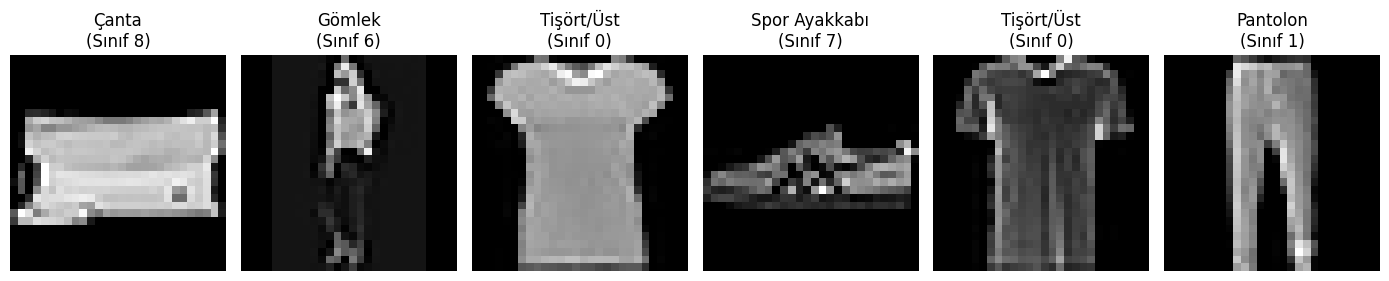

In [37]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Fashion-MNIST için etiket isimleri (0'dan 9'a kadar)
etiket_isimleri = {
    0: "Tişört/Üst", 1: "Pantolon", 2: "Kazak", 3: "Elbise", 4: "Kaban",
    5: "Sandalet", 6: "Gömlek", 7: "Spor Ayakkabı", 8: "Çanta", 9: "Bilekte Bot"
}

# Veri setini indirirken ToTensor() ile doğrudan [0, 1] aralığına normalize edilmiş PyTorch tensörlerine çeviriyoruz.
transform = transforms.Compose([
    transforms.ToTensor()
])

# Eğitim ve test veri setlerini indiriyoruz (Artık Fashion-MNIST kullanıyoruz)
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# Verileri modele küçük paketler (batch) halinde vermek için DataLoader kullanıyoruz
# batch_size=64: Her adımda modele 64 görsel verilecek
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Eğitim veri seti boyutu: {len(train_dataset)} görsel")
print(f"Test veri seti boyutu: {len(test_dataset)} görsel")

# DataLoader'dan bir batch çekip içeriğine bakalım
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\nBir batch'in tensör boyutu: {images.shape} (batch, kanal, yükseklik, genişlik)")

# İlk 6 görseli ekranda gösterelim
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i in range(6):
    axes[i].imshow(images[i].squeeze().numpy(), cmap='gray')
    sinif_ismi = etiket_isimleri[labels[i].item()]
    axes[i].set_title(f"{sinif_ismi}\n(Sınıf {labels[i].item()})")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Fashion-MNIST ile BasitCNN Modelinin Eğitimi

Artık verimiz hazır olduğuna göre, modelimizi eğitebiliriz. Eğitim süreci şu adımları içerir:
1. Modelin ileri yayılım (forward pass) yaparak tahmin üretmesi.
2. Tahmin ile gerçek etiket arasındaki hatanın (loss) hesaplanması.
3. Hatanın geri yayılım (backward pass) ile ağa iletilmesi.
4. Optimizasyon algoritmasının (Adam) ağırlıkları güncellemesi.

Colab (CPU) üzerinde çok uzun sürmemesi için eğitimi şimdilik sadece 2 epoch (tüm veri setinin üzerinden 2 kere geçmek) ile sınırlayacağız.

In [38]:
# Modelin ağırlıklarını sıfırlamak için yeniden başlatıyoruz
model_cnn = BasitCNN(num_classes=10).to(device)

# Kayıp fonksiyonu ve Optimizer'ı tanımlıyoruz
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

num_epochs = 2 # Eğitim süresini kısa tutmak için 2 epoch

print("Eğitim başlıyor...")
for epoch in range(num_epochs):
    model_cnn.train() # Modeli eğitim (training) moduna alıyoruz (Dropout ve BatchNorm için kritik)
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        # Verileri kullandığımız cihaza (CPU veya GPU) taşıyoruz
        images = images.to(device)
        labels = labels.to(device)

        # 1. İleri Yayılım (Forward Pass)
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        # 2. Geri Yayılım ve Optimizasyon (Backward Pass & Optimize)
        optimizer.zero_grad() # Önceki adımdan kalan gradyanları temizle
        loss.backward()       # Hatayı geriye doğru yayarak gradyanları hesapla
        optimizer.step()      # Ağırlıkları güncelle

        running_loss += loss.item()

        # Her 300 adımda bir (batch) ilerlemeyi ekrana yazdır
        if (i+1) % 300 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Adım [{i+1}/{len(train_loader)}], Kayıp (Loss): {running_loss/300:.4f}")
            running_loss = 0.0

print("Eğitim tamamlandı!")

Eğitim başlıyor...
Epoch [1/2], Adım [300/938], Kayıp (Loss): 0.5597
Epoch [1/2], Adım [600/938], Kayıp (Loss): 0.3917
Epoch [1/2], Adım [900/938], Kayıp (Loss): 0.3492
Epoch [2/2], Adım [300/938], Kayıp (Loss): 0.3044
Epoch [2/2], Adım [600/938], Kayıp (Loss): 0.3122
Epoch [2/2], Adım [900/938], Kayıp (Loss): 0.2930
Eğitim tamamlandı!


### Modelin Başarısını (Accuracy) Test Etme

Modelimizi eğittikten sonra, eğitim sırasında hiç görmediği **10.000 adet test görseli** üzerinde ne kadar başarılı olduğuna bakmalıyız.

In [39]:
# Modeli değerlendirme (evaluation) moduna alıyoruz
model_cnn.eval()

dogru_tahmin = 0
toplam_veri = 0

# Çıkarım (inference) aşamasında gradyan hesaplamaya gerek yoktur
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)

        # Her bir görsel için en yüksek skora (olasılığa) sahip olan sınıfı seç
        _, predicted = torch.max(outputs.data, 1)

        toplam_veri += labels.size(0)
        dogru_tahmin += (predicted == labels).sum().item()

dogruluk = 100 * dogru_tahmin / toplam_veri
print(f"Modelin 10.000 test görüntüsü üzerindeki doğruluğu: %{dogruluk:.2f}")

Modelin 10.000 test görüntüsü üzerindeki doğruluğu: %89.69


---
## 2. U-Net

### Konu Anlatımı

U-Net, orijinal olarak tıbbi görüntü segmentasyonu için geliştirilmiş, ancak
günümüzde her türlü **piksel bazlı segmentasyon** görevinde kullanılan bir
mimaridir. Adını, ağın "U" harfine benzeyen simetrik yapısından alır.

İki ana yoldan oluşur:

1. **Daraltma Yolu (Encoder / Contracting Path):**
   Klasik bir CNN gibi çalışır: art arda konvolüsyon + havuzlama katmanları
   ile görüntünün **uzamsal boyutu küçülür** ama **kanal (özellik) sayısı
   artar**. Bu yol "ne var" sorusuna cevap arar (bağlamsal/semantic bilgi).

2. **Genişletme Yolu (Decoder / Expanding Path):**
   Ters işlem uygulanır: transpoze konvolüsyon (upsampling) ile uzamsal
   boyut tekrar büyütülür. Bu yol "nerede" sorusuna cevap arar.

3. **Atlama Bağlantıları (Skip Connections):**
   U-Net'in en kritik özelliği budur. Encoder'daki her seviyenin çıktısı,
   decoder'daki aynı seviyeye **doğrudan bağlanır (concatenate)**. Bu sayede
   havuzlama sırasında kaybolan ince mekansal detaylar (nesne sınırları gibi)
   decoder'a geri taşınır ve segmentasyon çok daha keskin sınırlarla yapılır.

**Çıktı:** Girdiyle aynı boyutta (H x W), her pikselin hangi sınıfa ait
olduğunu gösteren bir "maske" (segmentasyon haritası).

**Tipik kullanım alanı:** Tümör/organ segmentasyonu, uydu görüntülerinde arazi
sınıflandırma, otonom araçlarda yol/şerit segmentasyonu.


In [22]:
class ConvBlok(nn.Module):
    """
    U-Net'te tekrar tekrar kullanılan temel yapı taşı:
    (Konvolüsyon -> BatchNorm -> ReLU) x 2
    Bu blok hem encoder hem decoder tarafında kullanılır.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.blok = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),  # Uzamsal boyutu koru (padding=1)
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),  # İkinci konvolüsyon, kanal sayısı sabit kalır
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.blok(x)  # Sequential içindeki tüm katmanları sırayla uygula


In [23]:
class UNet(nn.Module):
    """
    Basitleştirilmiş U-Net mimarisi.
    Giriş : (batch, in_ch, H, W)  -- örn. RGB görüntü (in_ch=3)
    Çıkış : (batch, num_classes, H, W) -- her piksel için sınıf skorları
    """
    def __init__(self, in_ch=3, num_classes=1, ozellikler=[64, 128, 256, 512]):
        super().__init__()

        self.encoder = nn.ModuleList()  # Daraltma yolundaki blokları tutacak liste
        self.decoder = nn.ModuleList()  # Genişletme yolundaki blokları tutacak liste
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Her encoder adımından sonra boyutu yarıya indirir

        # --- ENCODER (Daraltma Yolu) oluşturuluyor ---
        kanal = in_ch
        for f in ozellikler:
            self.encoder.append(ConvBlok(kanal, f))  # örn: 3->64, 64->128, 128->256, 256->512
            kanal = f

        # --- BOTTLENECK (En dar/derin katman, encoder ile decoder arasındaki köprü) ---
        self.bottleneck = ConvBlok(ozellikler[-1], ozellikler[-1] * 2)  # 512 -> 1024

        # --- DECODER (Genişletme Yolu) oluşturuluyor ---
        # Ozellikler listesini ters çeviriyoruz çünkü decoder küçükten büyüğe değil,
        # derinden (dar) sığa (geniş) doğru ilerler
        for f in reversed(ozellikler):
            # Transpoze konvolüsyon: özellik haritasının boyutunu 2 katına çıkarır (upsampling)
            self.decoder.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
            )
            # Skip connection ile birleştirildikten sonra kanal sayısı 2 katına çıkar (f*2),
            # bu yüzden ConvBlok girişi f*2 olarak ayarlanır
            self.decoder.append(ConvBlok(f * 2, f))

        # Son katman: kanal sayısını istenen sınıf sayısına indirir (1x1 konvolüsyon)
        self.son_katman = nn.Conv2d(ozellikler[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_baglantilari = []  # Her encoder seviyesinin çıktısını burada saklayacağız

        # --- Encoder'dan geçiş ---
        for enc_blok in self.encoder:
            x = enc_blok(x)                # Konvolüsyon bloğunu uygula
            skip_baglantilari.append(x)    # Havuzlamadan ÖNCEKİ hali sakla (decoder'a taşınacak)
            x = self.pool(x)               # Boyutu yarıya indir

        # --- Bottleneck ---
        x = self.bottleneck(x)  # En derin katman

        # Skip bağlantılarını decoder'da kullanmak için ters çeviriyoruz
        # (en son eklenen encoder çıktısı, decoder'da en önce kullanılır)
        skip_baglantilari = skip_baglantilari[::-1]

        # --- Decoder'dan geçiş ---
        # self.decoder listesinde ikişerli gidiyoruz: [upsample, convblok, upsample, convblok, ...]
        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)                    # Transpoze konvolüsyon ile boyutu büyüt
            skip = skip_baglantilari[i // 2]           # İlgili encoder seviyesinin sakladığı özellik haritası

            # Boyutlar (yuvarlama hatalarından dolayı) tam eşleşmeyebilir, gerekirse kırp
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])  # skip ile aynı H,W boyutuna getir

            x = torch.cat((skip, x), dim=1)           # KRİTİK ADIM: skip connection -> kanal boyutunda birleştir
            x = self.decoder[i + 1](x)                # ConvBlok ile işle

        return self.son_katman(x)  # Son 1x1 konvolüsyon ile sınıf haritasını üret


In [24]:
# U-Net modelini oluşturuyoruz: 3 kanallı (RGB) girdi, 1 sınıflı çıktı (örn. ikili segmentasyon: nesne/arkaplan)
model_unet = UNet(in_ch=3, num_classes=1).to(device)

# Sahte bir RGB görüntü batch'i: (batch=2, kanal=3, yükseklik=160, genişlik=160)
sahte_goruntu = torch.randn(2, 3, 160, 160).to(device)
maske_ciktisi = model_unet(sahte_goruntu)

print(f"Girdi boyutu : {sahte_goruntu.shape}")
print(f"Çıktı boyutu : {maske_ciktisi.shape}  # Girdiyle aynı H,W -> piksel bazlı segmentasyon haritası")

# Toplam öğrenilebilir parametre sayısı
toplam_param = sum(p.numel() for p in model_unet.parameters())
print(f"Toplam parametre sayısı: {toplam_param:,}")


Girdi boyutu : torch.Size([2, 3, 160, 160])
Çıktı boyutu : torch.Size([2, 1, 160, 160])  # Girdiyle aynı H,W -> piksel bazlı segmentasyon haritası
Toplam parametre sayısı: 31,043,521


**Kayıp fonksiyonu notu:** Segmentasyon görevlerinde genellikle
`BCEWithLogitsLoss` (ikili segmentasyon için) veya `CrossEntropyLoss`
(çok sınıflı segmentasyon için) kullanılır; ayrıca sınırların örtüşme
kalitesini ölçen **Dice Loss** de sıkça bu kayıplarla birlikte kullanılır.

---
## 3. Mask R-CNN

### Konu Anlatımı

Mask R-CNN, **nesne tespiti (object detection)** ile **örnek segmentasyonunu
(instance segmentation)** aynı anda yapan bir mimaridir. U-Net'ten farkı:
U-Net görüntüdeki "kedi bölgesi" gibi bir sınıf maskesi üretirken, Mask R-CNN
her bir **nesne örneğini ayrı ayrı** tespit eder (örn. görüntüdeki 3 farklı
köpeği birbirinden ayırt eder) ve her biri için hem sınırlayıcı kutu
(bounding box) hem de o nesneye özel bir maske üretir.

Mimarinin temel bileşenleri:

1. **Omurga Ağı (Backbone, örn. ResNet + FPN):**
   Görüntüden çok ölçekli özellik haritaları çıkarır.

2. **Bölge Öneri Ağı (Region Proposal Network - RPN):**
   Görüntüde nesne olabilecek aday bölgeleri (region proposals) hızlıca
   önerir.

3. **RoIAlign:**
   Faster R-CNN'deki RoIPooling'in daha hassas bir versiyonudur; aday
   bölgeleri sabit boyutlu özellik haritalarına dönüştürürken piksel
   hizalama hatalarını önler (maske kalitesi için kritiktir).

4. **Üç Paralel Çıkış Başlığı (Head):**
   - **Sınıflandırma başlığı:** Nesnenin hangi sınıfa ait olduğunu tahmin eder
   - **Kutu regresyon başlığı:** Sınırlayıcı kutunun koordinatlarını hassaslaştırır
   - **Maske başlığı:** Küçük bir FCN (Fully Convolutional Network) ile o
     nesneye özel ikili (binary) piksel maskesini üretir

**Tipik kullanım alanı:** Otonom sürüş (araç/yaya sayma ve sınırlama),
video izleme, tıbbi görüntülerde çoklu hücre/lezyon tespiti.

Aşağıda, sıfırdan mimari kurmak yerine (bu çok karmaşık olur),
`torchvision`'ın hazır Mask R-CNN mimarisini kullanıp **kendi sınıf
sayımıza göre uyarlıyoruz** — gerçek projelerde de yaygın yaklaşım budur
(transfer learning).


In [25]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def mask_rcnn_olustur(num_classes):
    """
    COCO veri setiyle önceden eğitilmiş (pretrained) Mask R-CNN modelini yükler
    ve son katmanlarını kendi sınıf sayımıza göre değiştirir (transfer learning).

    num_classes: arkaplan dahil toplam sınıf sayısı (örn. 2 = arkaplan + 1 nesne sınıfı)
    """
    # weights="DEFAULT": ImageNet/COCO üzerinde önceden eğitilmiş ağırlıkları indirir
    # Bu sayede sıfırdan eğitmek yerine, öğrenilmiş genel görsel özelliklerden faydalanırız
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # --- 1. Sınıflandırma + Kutu Regresyon Başlığını Değiştir ---
    in_features = model.roi_heads.box_predictor.cls_score.in_features  # Mevcut özellik boyutunu al
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # --- 2. Maske Başlığını Değiştir ---
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Maske başlığındaki gizli katman boyutu
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model


In [26]:
# Örnek: arkaplan + 2 nesne sınıfı (toplam 3 sınıf) için model oluşturuyoruz
NUM_CLASSES = 3  # örn: 0=arkaplan, 1=kedi, 2=köpek
model_maskrcnn = mask_rcnn_olustur(NUM_CLASSES).to(device)
model_maskrcnn.eval()  # Değerlendirme (inference) moduna al (BatchNorm/Dropout davranışını sabitler)

print("Mask R-CNN modeli başarıyla oluşturuldu.")
print(f"Toplam parametre sayısı: {sum(p.numel() for p in model_maskrcnn.parameters()):,}")


Mask R-CNN modeli başarıyla oluşturuldu.
Toplam parametre sayısı: 43,927,777


In [27]:
# --- Çıkarım (Inference) Örneği ---
# Mask R-CNN, girdi olarak [0,1] aralığında normalize edilmiş RGB görüntü listesi bekler
# (sabit boyut şartı yoktur, model içeride kendi ölçekler)

sahte_goruntu_listesi = [torch.rand(3, 300, 400).to(device)]  # 1 adet sahte RGB görüntü

with torch.no_grad():  # Çıkarım sırasında gradyan hesaplamayı kapatıyoruz (bellek/hız için)
    tahminler = model_maskrcnn(sahte_goruntu_listesi)

# Model her görüntü için bir sözlük (dict) döndürür:
# 'boxes'  -> tespit edilen her nesnenin sınırlayıcı kutu koordinatları [x1,y1,x2,y2]
# 'labels' -> her kutunun tahmin edilen sınıf etiketi
# 'scores' -> her tahminin güven skoru (0-1 arası)
# 'masks'  -> her nesne için piksel bazlı ikili maske (1, H, W) boyutunda

tek_goruntu_sonucu = tahminler[0]
print("Çıktı anahtarları:", tek_goruntu_sonucu.keys())
print(f"Tespit edilen kutu sayısı : {tek_goruntu_sonucu['boxes'].shape}")
print(f"Maske tensör boyutu       : {tek_goruntu_sonucu['masks'].shape}")
print(f"Skor örnekleri (ilk 5)    : {tek_goruntu_sonucu['scores'][:5]}")


Çıktı anahtarları: dict_keys(['boxes', 'labels', 'scores', 'masks'])
Tespit edilen kutu sayısı : torch.Size([100, 4])
Maske tensör boyutu       : torch.Size([100, 1, 300, 400])
Skor örnekleri (ilk 5)    : tensor([0.4387, 0.4368, 0.4339, 0.4323, 0.4289])


**Eğitim notu:** Mask R-CNN'i kendi verinizle eğitmek için her görüntüye
karşılık `boxes`, `labels` ve `masks` içeren hedef (target) sözlükleri
hazırlamanız ve `torchvision.datasets` formatına uygun bir `Dataset` sınıfı
yazmanız gerekir. Model eğitim modundayken (`model.train()`) hem sınıflandırma
hem kutu hem de maske kayıplarını otomatik olarak birlikte hesaplar ve
`loss_dict` olarak döner; bu kayıpların toplamı geri yayılım için kullanılır.


---
## Özet Karşılaştırma

| Özellik | CNN | U-Net | Mask R-CNN |
|---|---|---|---|
| **Görev** | Sınıflandırma | Semantik segmentasyon | Nesne tespiti + örnek segmentasyonu |
| **Çıktı** | Tek etiket/görüntü | Piksel bazlı sınıf haritası | Kutu + sınıf + nesne bazlı maske |
| **Nesneleri ayırt eder mi?** | Hayır | Hayır (aynı sınıf tek maskede birleşir) | Evet (her nesne ayrı) |
| **Mimari karmaşıklığı** | Düşük | Orta | Yüksek |
| **Tipik kullanım** | "Bu görüntü ne?" | "Hangi piksel hangi sınıfa ait?" | "Kaç nesne var, nerede, sınırları ne?" |

### Sonraki Adımlar
- Gerçek bir veri seti ile (örn. `torchvision.datasets.MNIST`, Kaggle segmentasyon setleri, COCO) eğitim döngüsünü tamamlayabilirsiniz.
- `DataLoader` kullanarak batch'ler halinde veri besleme eklenebilir.
- Eğitim/doğrulama kaybı grafikleri (`matplotlib`) ile izlenebilir.
- Model ağırlıkları `torch.save(model.state_dict(), "model.pth")` ile kaydedilebilir.


### Örnek Görüntü Yükleme ve Gösterme

Yukarıda incelenen derin öğrenme modelleriyle çalışmak için gerçek görüntü verilerine ihtiyacımız var. Aşağıda, `torchvision.datasets` aracılığıyla MNIST veri setinden basit bir gri tonlamalı görüntüyü nasıl yükleyip görüntüleyebileceğinizi gösteren bir örnek bulunmaktadır.

Kendi görüntülerinizle çalışmak için, `PIL` (Pillow) kütüphanesini kullanarak görüntüleri okuyabilir, ardından `torchvision.transforms` ile modeli için uygun formata (boyut, normalizasyon, tensör dönüşümü vb.) dönüştürebilirsiniz.

**Görsel yükleme hatası düzeltmesi:** Daha önce web'den görsel yüklemede 'cannot identify image file' hatası alınmıştı. Bu, `PIL`'in `requests`'tan gelen `BytesIO` akışını doğrudan bir dosya gibi okuyamamasından kaynaklanabilir. Bu sorunu çözmek için `requests.get(image_path, stream=True).raw` kullanıldı. Bu yöntem, `PIL`'in ham yanıt içeriğini doğrudan bir dosya gibi okumasını sağlayarak daha sağlam bir çözüm sunar.

İşlenmiş görselin tensör boyutu: torch.Size([1, 28, 28])


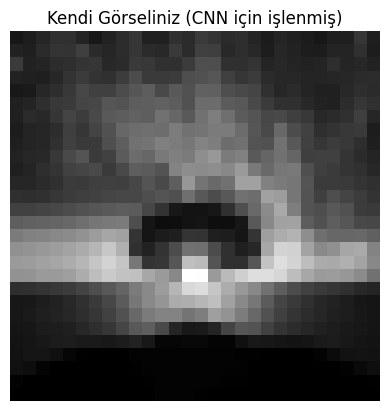

In [28]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import requests

# Kendi görselinizin dosya yolunu buraya ekleyin veya web adresini kullanın.
# Örnek: 'path/to/your/image.jpg'
# Daha güvenilir bir URL örneği: 'https://cdn.pixabay.com/photo/2015/04/23/22/00/tree-736885_1280.jpg'
image_path = 'https://cdn.pixabay.com/photo/2015/04/23/22/00/tree-736885_1280.jpg' # Örnek bir görsel

# CNN modeli (BasitCNN) 1 kanallı (gri tonlamalı) ve 28x28 boyutunda girdi bekler.
# Kendi görseliniz için gerekli dönüşümleri burada tanımlayın.
# Bu örnekte, görseli gri tonlamalıya çevirip 28x28 boyutuna getiriyoruz.
transform_custom_image = transforms.Compose([
    transforms.Resize((28, 28)),          # Görseli 28x28 boyuta getir
    transforms.Grayscale(num_output_channels=1), # Gri tonlamalıya çevir (1 kanal)
    transforms.ToTensor()                # PyTorch tensörüne çevir (0-1 aralığında normalleştirir)
])

try:
    # Görseli web'den yükle
    # requests.get(url, stream=True).raw ile doğrudan bir dosya benzeri nesne alıyoruz,
    # bu, PIL'in görseli daha güvenilir bir şekilde tanımasını sağlar.
    response = requests.get(image_path, stream=True)
    response.raise_for_status() # HTTP hatalarını kontrol et
    img = Image.open(response.raw)

    # Dönüşümleri uygula
    processed_image = transform_custom_image(img)

    # Modela vermek için batch boyutu ekle: (1, 1, 28, 28)
    image_for_model = processed_image.unsqueeze(0)

    print(f"İşlenmiş görselin tensör boyutu: {processed_image.shape}")

    # Görseli göstermek için matplotlib kullanıyoruz
    # `processed_image.squeeze().numpy()`: Tek kanallı boyutu kaldırır (örn. (1, 28, 28) -> (28, 28)) ve numpy dizisine çevirir
    plt.imshow(processed_image.squeeze().numpy(), cmap='gray') # Gri tonlamalı görüntü için 'gray' renk haritası
    plt.title("Kendi Görseliniz (CNN için işlenmiş)")
    plt.axis('off') # Eksen etiketlerini kapat
    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Web'den görsel yüklenirken bir ağ hatası oluştu: {e}")
except FileNotFoundError:
    print(f"Hata: '{image_path}' yolunda bir görsel bulunamadı. Lütfen doğru yolu girdiğinizden emin olun.")
except Exception as e:
    print(f"Görsel işlenirken bir hata oluştu: {e}")


### Özel Görseli CNN Modelinde Kullanma

Şimdi önceden işlediğimiz özel görseli (`image_for_model`) `BasitCNN` modelimize girdi olarak verelim ve modelin tahmin skorlarını (`logits`) inceleyelim. Model bu ham skorları 10 farklı sınıf için üretecektir (MNIST benzeri bir sınıflandırma için).

In [29]:
# Modeli değerlendirme moduna alıyoruz
model_cnn.eval()

# Gradyan hesaplamayı kapatıyoruz (çıkarım için gerekli)
with torch.no_grad():
    # İşlenmiş özel görseli modele girdi olarak veriyoruz
    # image_for_model zaten (1, 1, 28, 28) boyutunda olduğu için doğrudan kullanılabilir.
    # Modeli doğru cihaza taşıdığımızdan emin olmalıyız.
    cnn_ciktisi = model_cnn(image_for_model.to(device))

print(f"CNN modelinin çıktı (logits) boyutu: {cnn_ciktisi.shape}")
print("CNN modelinin ham çıktıları (logits):")
print(cnn_ciktisi)

# Logits'leri olasılıklara dönüştürmek için Softmax kullanabiliriz
probabilities = F.softmax(cnn_ciktisi, dim=1)
print("\nTahmin olasılıkları (Softmax uygulanmış):")
print(probabilities)

# En yüksek olasılığa sahip sınıfı bulalım
predicted_class = torch.argmax(probabilities, dim=1)
print(f"\nModelin tahmin ettiği sınıf (indeks): {predicted_class.item()}")

CNN modelinin çıktı (logits) boyutu: torch.Size([1, 10])
CNN modelinin ham çıktıları (logits):
tensor([[-0.0340, -0.0420, -0.0832,  0.0145, -0.0388,  0.0020, -0.0101, -0.0139,
          0.0994, -0.0680]])

Tahmin olasılıkları (Softmax uygulanmış):
tensor([[0.0982, 0.0975, 0.0935, 0.1031, 0.0978, 0.1018, 0.1006, 0.1002, 0.1123,
         0.0950]])

Modelin tahmin ettiği sınıf (indeks): 8


### Özel Görseli U-Net Modelinde Kullanma

`BasitCNN` modelinde olduğu gibi, `U-Net` modelini de özel bir görselle test edebiliriz. U-Net, 3 kanallı (RGB) girdi ve tipik olarak `160x160` gibi boyutlar bekler. Modelden çıkan çıktı, segmentasyon maskesidir.

İşlenmiş görselin U-Net için tensör boyutu: torch.Size([1, 3, 160, 160])
U-Net modelinin çıktı (maske) boyutu: torch.Size([1, 1, 160, 160])


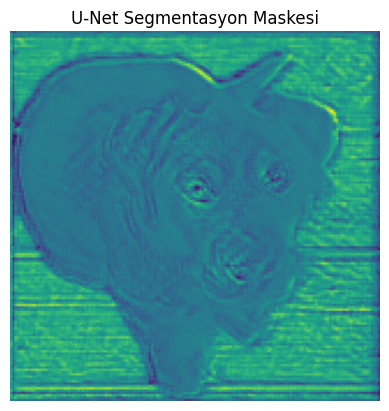

In [32]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import requests

# Kendi görselinizin dosya yolunu buraya ekleyin veya web adresini kullanın.
# U-Net için bir örnek görsel (genellikle daha büyük çözünürlük istenir)
# Önceki URL'ler 403 hatası verdiği için daha güvenilir bir URL ile değiştirildi.
image_path_unet = 'https://picsum.photos/id/237/160/160' # Rastgele bir köpek görseli (örnek olarak)

# U-Net modeli 3 kanallı (RGB) ve esnek bir boyut bekleyebilir, ancak genellikle belirli bir boyuta ölçeklenir.
# Burada 160x160'a ölçekliyoruz, çünkü model testi için bu boyut kullanılmıştı.
transform_unet_image = transforms.Compose([
    transforms.Resize((160, 160)),         # U-Net için boyuta getir
    transforms.ToTensor()                  # PyTorch tensörüne çevir (0-1 aralığında normalleştirir)
])

try:
    # Görseli web'den yükle
    response_unet = requests.get(image_path_unet, stream=True)
    response_unet.raise_for_status() # HTTP hatalarını kontrol et
    img_unet = Image.open(response_unet.raw).convert('RGB') # U-Net için RGB'ye çevir

    # Dönüşümleri uygula
    processed_image_unet = transform_unet_image(img_unet)

    # Modela vermek için batch boyutu ekle: (1, 3, 160, 160)
    image_for_unet_model = processed_image_unet.unsqueeze(0)

    print(f"İşlenmiş görselin U-Net için tensör boyutu: {image_for_unet_model.shape}")

    # Modeli değerlendirme moduna alıyoruz
    model_unet.eval()

    # Gradyan hesaplamayı kapatıyoruz (çıkarım için gerekli)
    with torch.no_grad():
        # İşlenmiş özel görseli U-Net modeline girdi olarak veriyoruz
        unet_ciktisi = model_unet(image_for_unet_model.to(device))

    print(f"U-Net modelinin çıktı (maske) boyutu: {unet_ciktisi.shape}")

    # Çıkan maskeyi görselleştirmek için (sigmoid aktivasyonundan sonra)
    # U-Net'in son katmanı sigmoid veya benzeri bir aktivasyon içermiyorsa, manuel uygulamak gerekebilir.
    # Bu örnekte, çıktı logits'ler olduğundan, onu olasılıklara dönüştürmek için sigmoid uygulayalım.
    mask_probabilities = torch.sigmoid(unet_ciktisi)

    # İlk batch'teki maskeyi numpy'ye çevir ve göster
    # Squeeze: (1, 1, H, W) -> (H, W)
    # U-Net genellikle 1 kanal (binary mask) veya num_classes kanal döndürür.
    # Eğer num_classes > 1 ise, görselleştirme için argmax alıp renklendirmek gerekebilir.
    # Bu örnekte num_classes=1 olduğu için 0. kanalı alıyoruz.
    plt.imshow(mask_probabilities[0, 0].cpu().numpy(), cmap='viridis') # Tek kanallı maske
    plt.title("U-Net Segmentasyon Maskesi")
    plt.axis('off')
    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Web'den görsel yüklenirken bir ağ hatası oluştu: {e}. Lütfen başka bir URL deneyin.")
except Exception as e:
    print(f"Görsel işlenirken veya U-Net modelinde hata oluştu: {e}")

### Özel Görseli Mask R-CNN Modelinde Kullanma

Şimdi Mask R-CNN modelini özel bir görsel üzerinde test edelim. Mask R-CNN, girdi olarak normalleştirilmiş (0-1 aralığında) RGB görüntü tensörleri listesi bekler ve çıktı olarak tespit edilen nesneler için sınırlayıcı kutular, etiketler, güven skorları ve segmentasyon maskeleri döndürür. Bu örnekte, `torchvision.transforms.ToTensor()` metodu otomatik olarak 0-255 piksel değerlerini 0-1 aralığına normalize eder.

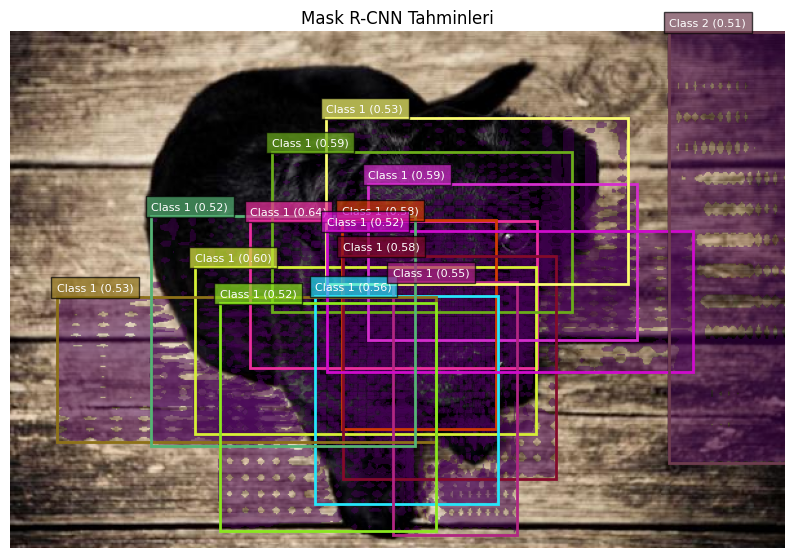

Tespit edilen toplam nesne sayısı (eşik 0.5 üzeri): 14
Tahmin edilen etiketler (eşik üzeri): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2]


In [35]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
import random
import numpy as np # numpy eklendi

# Mask R-CNN için kullanılacak özel görsel URL'si
# Nesneleri olan daha çeşitli bir görsel seçelim.
# COCO veri setinde yaygın olan bir nesneyi (örneğin köpek) içeren bir görsel ile değiştirildi.
image_path_maskrcnn = 'https://picsum.photos/id/237/600/400' # Rastgele bir köpek görseli

# Mask R-CNN modeli, RGB tensörleri bekler ve boyutu esnektir.
# ToTensor, görüntüleri 0-1 aralığına otomatik olarak normalleştirir.
transform_maskrcnn_image = transforms.Compose([
    transforms.ToTensor()  # PyTorch tensörüne çevir (0-1 aralığında normalleştirir)
])

try:
    # Görseli web'den yükle
    response_maskrcnn = requests.get(image_path_maskrcnn, stream=True)
    response_maskrcnn.raise_for_status() # HTTP hatalarını kontrol et
    img_maskrcnn = Image.open(response_maskrcnn.raw).convert('RGB') # RGB'ye çevir

    # Dönüşümleri uygula
    processed_image_maskrcnn = transform_maskrcnn_image(img_maskrcnn)

    # Modeli değerlendirme moduna alıyoruz
    model_maskrcnn.eval()

    # Gradyan hesaplamayı kapatıyoruz (çıkarım için gerekli)
    with torch.no_grad():
        # İşlenmiş özel görseli Mask R-CNN modeline girdi olarak veriyoruz (liste içinde olmalı)
        # to(device) ile modeli ve girdiyi aynı cihaza taşıyoruz.
        predictions = model_maskrcnn([processed_image_maskrcnn.to(device)])

    # Tahmin sonuçlarını al (ilk görüntü için)
    pred = predictions[0]

    # Görselleştirme
    fig, ax = plt.subplots(1, figsize=(10, 8))
    # Orijinal görseli göster (tensörü numpy'ye çevir ve permute ile eksen sırasını düzelt)
    ax.imshow(processed_image_maskrcnn.cpu().permute(1, 2, 0).numpy())
    ax.set_title("Mask R-CNN Tahminleri")
    ax.axis('off')

    # Her bir tespit edilen nesne için kutu ve maskeyi çiz
    # Güven skoru eşiği belirle
    score_threshold = 0.5 # Sadece yeterince yüksek skorlu tahminleri göster (0.7'den 0.5'e düşürüldü)
    for i in range(len(pred['boxes'])):
        score = pred['scores'][i].item()
        if score > score_threshold:
            box = pred['boxes'][i].cpu().numpy()
            label = pred['labels'][i].item()
            mask = pred['masks'][i, 0].cpu().numpy() # [0] -> tek kanallı maskeyi al

            # Renk seçimi (rastgele bir renk)
            color = [random.random() for _ in range(3)]

            # Bounding Box çiz
            rect = patches.Rectangle(
                (box[0], box[1]), box[2] - box[0], box[3] - box[1],
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)

            # Maskeyi çiz
            # Maske genellikle 0-1 aralığında olasılıklar döndürür, eşikleme yapalım.
            mask_binary = mask > 0.5
            ax.imshow(np.ma.masked_where(mask_binary == 0, mask_binary),
                      cmap='viridis', alpha=0.5)

            # Etiketi ve skoru yaz
            ax.text(box[0], box[1] - 5, f'Class {label} ({score:.2f})',
                    color='white', fontsize=8, bbox=dict(facecolor=color, alpha=0.7))

    plt.show()

    print(f"Tespit edilen toplam nesne sayısı (eşik {score_threshold} üzeri): {len([s for s in pred['scores'] if s.item() > score_threshold])}")
    if len(pred['labels']) > 0:
        print(f"Tahmin edilen etiketler (eşik üzeri): {[label.item() for label, score in zip(pred['labels'], pred['scores']) if score.item() > score_threshold]}")

except requests.exceptions.RequestException as e:
    print(f"Web'den görsel yüklenirken bir ağ hatası oluştu: {e}. Lütfen başka bir URL deneyin.")
except Exception as e:
    print(f"Görsel işlenirken veya Mask R-CNN modelinde hata oluştu: {e}")